In [ ]:
!pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 49.2 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.12.1
    Uninstalling transformers-5.12.1:
      Successfully uninstalled transformers-5.12.1


In [1]:
from google.colab import files
uploaded = files.upload()

Saving train-00000-of-00001.parquet to train-00000-of-00001.parquet


In [2]:
import pandas as pd
data = pd.read_parquet('train-00000-of-00001.parquet')
data.head()

,text,label
0,"Добрый день, устанавливал я на несколько серве...",0
1,"Нет, из-за файловой системы с ошибками.",0
2,"Читайте всё, что я написал. В Simply есть зафи...",0
3,Можно ли сделать так чтобы шрифт в терминале в...,0
4,"Это зависит от того, какой из полутора десятко...",0


In [6]:
import torch
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, f1_score


device = "cuda" if torch.cuda.is_available() else "cpu"

train_df, val_df = train_test_split(data, test_size=0.2, random_state=42, stratify=data['label'])

train_df = train_df.rename(columns={'label': 'labels'})
val_df = val_df.rename(columns={'label': 'labels'})

train_dataset = Dataset.from_dict(train_df)
val_dataset = Dataset.from_dict(val_df)

model_name = "deepvk/RuModernBERT-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_train = train_dataset.map(tokenize_function, batched=True, remove_columns=["text"])
tokenized_val = val_dataset.map(tokenize_function, batched=True, remove_columns=["text"])


model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="weighted")
    }


training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="steps",
    save_strategy="steps",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.05,
    load_best_model_at_end=True,
    logging_steps=250,
    report_to="none",
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=4
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

trainer.train()

Map:   0%|          | 0/17128 [00:00<?, ? examples/s]

Map:   0%|          | 0/4283 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: deepvk/RuModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/loca

Step,Training Loss,Validation Loss,Accuracy,F1
250,0.079317,0.017920,0.994863,0.994867
500,0.020569,0.023374,0.996731,0.996728
750,0.030500,0.021589,0.996031,0.996027
1000,0.015139,0.014525,0.998366,0.998365
1250,0.008840,0.020731,0.998132,0.998132
1500,0.006203,0.022922,0.998132,0.998132
1750,0.002090,0.021646,0.997665,0.997664
2000,0.001540,0.020946,0.998132,0.998132
2142,0.001540,0.020550,0.998366,0.998365


...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/to

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2142, training_loss=0.019529639728485593, metrics={'train_runtime': 857.1171, 'train_samples_per_second': 39.967, 'train_steps_per_second': 2.499, 'total_flos': 2918250193281024.0, 'train_loss': 0.019529639728485593, 'epoch': 2.0})

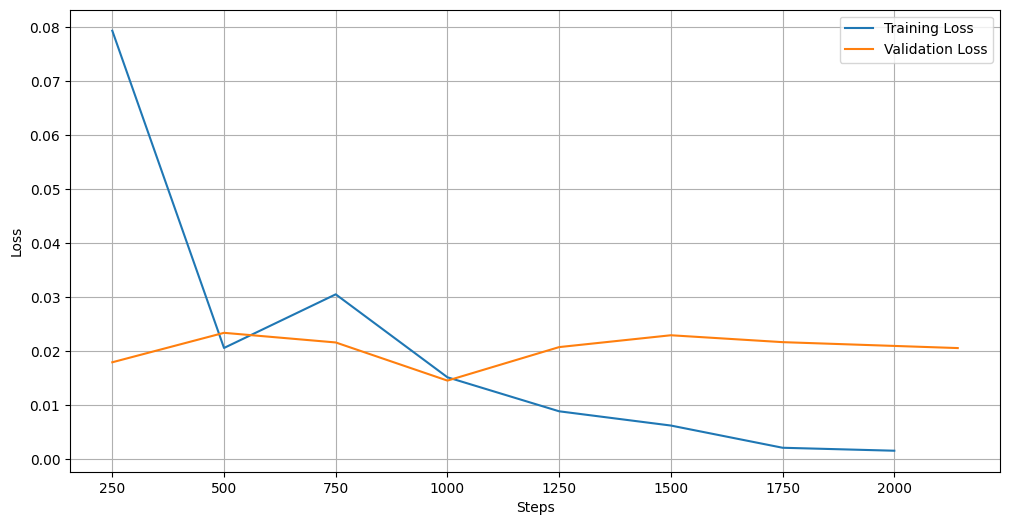

In [7]:
import matplotlib.pyplot as plt

logs = trainer.state.log_history

train_logs = [entry for entry in logs if 'loss' in entry and 'learning_rate' in entry]
train_steps = [entry['step'] for entry in train_logs]
train_loss = [entry['loss'] for entry in train_logs]

val_logs = [entry for entry in logs if 'eval_loss' in entry and 'step' in entry]
val_steps = [entry['step'] for entry in val_logs]
val_loss = [entry['eval_loss'] for entry in val_logs]

plt.figure(figsize=(12, 6))
plt.plot(train_steps, train_loss, label='Training Loss')
plt.plot(val_steps, val_loss, label='Validation Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
import os
from google.colab import files

output_dir = "./spam_model"

trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)

zip_filename = "spam_model.zip"
!zip -r {zip_filename} {output_dir}

files.download(zip_filename)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  adding: spam_model/ (stored 0%)
  adding: spam_model/tokenizer_config.json (deflated 44%)
  adding: spam_model/model.safetensors (deflated 7%)
  adding: spam_model/tokenizer.json (deflated 83%)
  adding: spam_model/config.json (deflated 71%)
  adding: spam_model/training_args.bin (deflated 53%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
loaded_tokenizer = AutoTokenizer.from_pretrained("./spam_model")
loaded_model = AutoModelForSequenceClassification.from_pretrained("./spam_model")

device = "cuda" if torch.cuda.is_available() else "cpu"
loaded_model.to(device)
loaded_model.eval()

def predict_sentiment(text):
    inputs = loaded_tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = loaded_model(**inputs)

    logits = outputs.logits
    prediction = torch.argmax(logits, dim=-1).item()

    if prediction == 0:
        return "Normal"
    else:
        return "Spam"
text_to_predict = "Это очень хороший продукт, мне все понравилось!"
predicted_label = predict_sentiment(text_to_predict)
print(f"Текст: \"{text_to_predict}\"")
print(f"Предсказание: {predicted_label}")

text_to_predict_2 = "Срочно нужны деньги? Заработай 1000$ в день!"
predicted_label_2 = predict_sentiment(text_to_predict_2)
print(f"\nТекст: \"{text_to_predict_2}\"")
print(f"Предсказание: {predicted_label_2}")

text_to_predict_3 = "Я думаю, что это не сработает."
predicted_label_3 = predict_sentiment(text_to_predict_3)
print(f"\nТекст: \"{text_to_predict_3}\"")
print(f"Предсказание: {predicted_label_3}")

Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

Текст: "Это очень хороший продукт, мне все понравилось!"
Предсказание: Normal

Текст: "Срочно нужны деньги? Заработай 1000$ в день!"
Предсказание: Spam

Текст: "Я думаю, что это не сработает."
Предсказание: Normal
